<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Exercise8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('/content/EFIplus_medit.csv')

In [38]:
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

print("Available columns after correcting delimiter:", df.columns.tolist())

# The original code attempted to use a 'Basin' column which does not exist.
# Please check the available columns above and replace 'Basin' with the correct column name if one exists for filtering.
# For example, if 'Catchment_name' is intended to be used:
# df_subset = df[df["Catchment_name"].isin(["Douro", "Tejo"])]

# The original line `df["Basin"],` is removed as it's a no-op that caused the error.
# The df_subset assignment is commented out because 'Basin' column is missing.
# df_subset = df[df["Basin"].isin(["Douro", "Tejo"])]

env_vars = [
    "Altitude",
    "Actual_river_slope", # Corrected from "Slope"
    "temp_ann",           # Corrected from "MeanAnnualTemp"
    "prec_ann_catch",     # Corrected from "MeanAnnualPrecip"
    # "DrainageArea",     # No direct match found. Please verify the intended column name.
    # "CurrentSpeed"      # No direct match found. Please verify the intended column name.
]

Available columns after correcting delimiter: ['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Wate

In [39]:
df_subset = df[df["Catchment_name"].isin(["Douro", "Tejo"])]
X = df_subset[env_vars]

In [40]:
X = X.dropna()

**Standardize Variables**

In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
distance_matrix = pdist(X_scaled, metric='euclidean')

**Run Agglomerative Clustering with Different Linkage Methods**

In [42]:
##Single Linkage
single_linkage = linkage(distance_matrix, method='single')

##Complete Linkage
complete_linkage = linkage(distance_matrix, method='complete')

##Average Linkage
average_linkage = linkage(distance_matrix, method='average')

##Plot Dendrograms

**Single_Linkage**


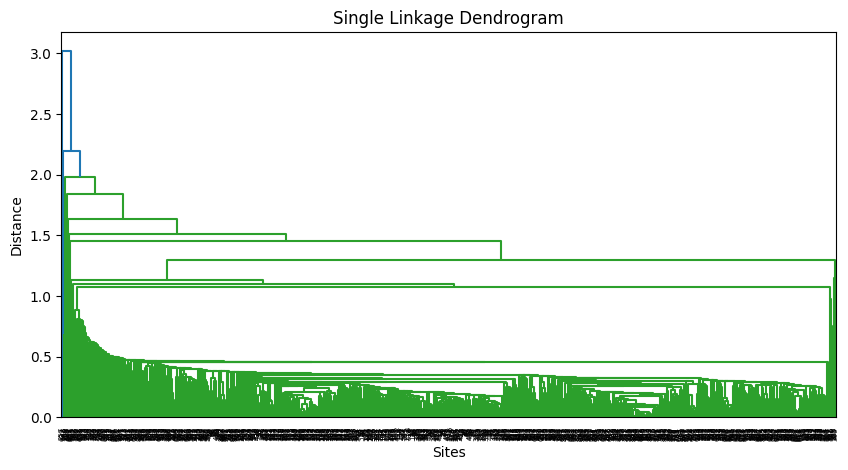

In [43]:
plt.figure(figsize=(10, 5))

dendrogram(single_linkage)

plt.title("Single Linkage Dendrogram")
plt.xlabel("Sites")
plt.ylabel("Distance")

plt.show()

##Complete Linkage





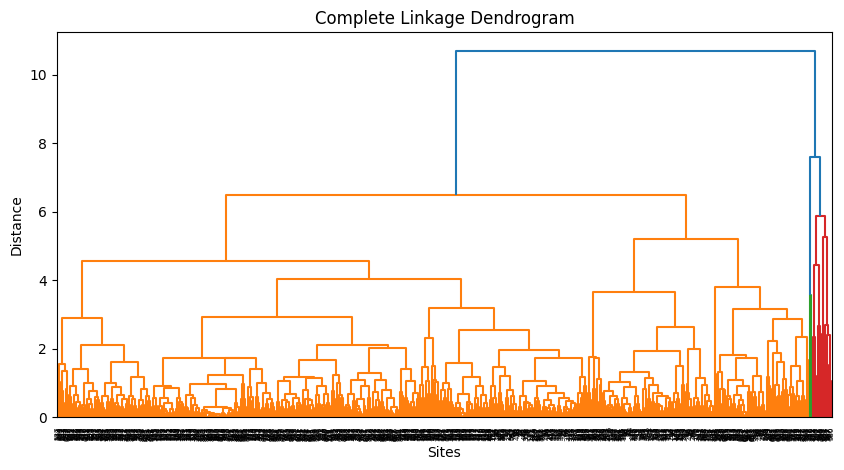

In [44]:
plt.figure(figsize=(10, 5))

dendrogram(complete_linkage)

plt.title("Complete Linkage Dendrogram")
plt.xlabel("Sites")
plt.ylabel("Distance")

plt.show()

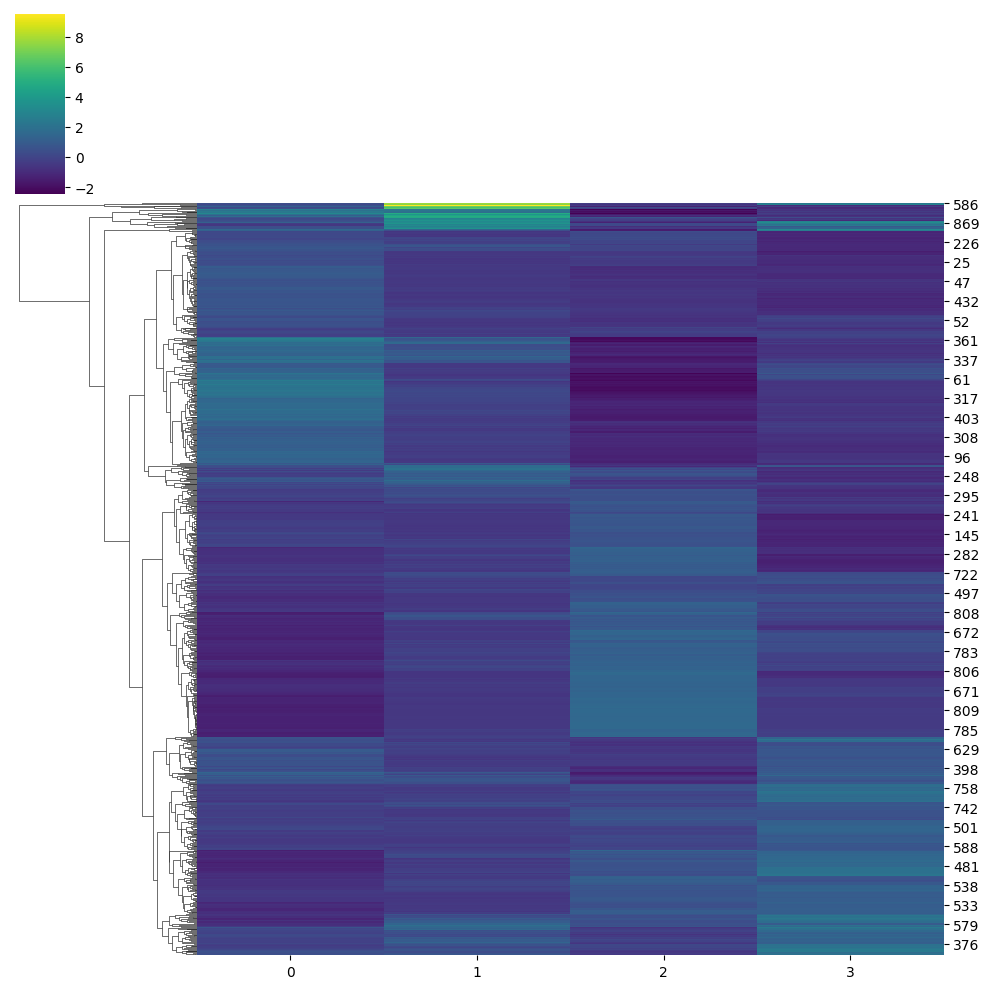

In [45]:
import seaborn as sns

# Average linkage clustering
row_linkage = linkage(X_scaled, method='average')

# Plot heatmap and dendrogram
sns.clustermap(
    X_scaled,
    row_linkage=row_linkage,
    col_cluster=False,
    cmap='viridis',
    figsize=(10,10)
)

plt.show()

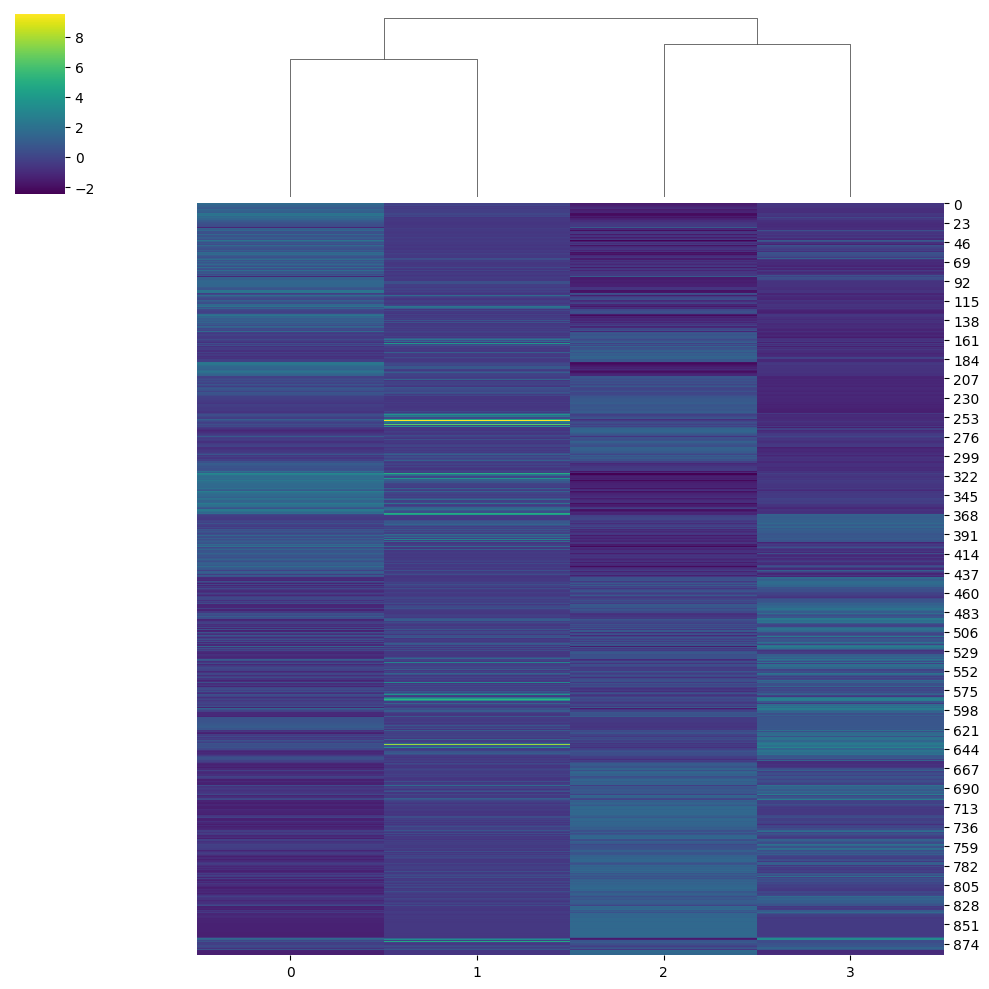

In [46]:
# Cluster environmental variables (columns)
col_linkage = linkage(X_scaled.T, method='average')

# Plot heatmap with column dendrogram
sns.clustermap(
    X_scaled,
    row_cluster=False,      # do not cluster rows
    col_linkage=col_linkage,
    cmap='viridis',
    figsize=(10,10)
)

plt.show()